In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


### Device Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,),
                         (0.5,0.5,0.5))
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform)
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.9MB/s]

Number of training samples: 60000
Number of testing samples: 10000


### Loading Pretrained VGG16



In [ ]:
model = models.vgg16(pretrained=True)
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False
# Replacing the final classifier layer
model.classifier[6] = nn.Linear(4096, 10)
model = model.to(device)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 178MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Loss Function and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[6].parameters(), lr=0.001)
epochs = 2

### Training Loop

In [ ]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/2], Loss: 0.6343
Epoch [2/2], Loss: 0.6288


### Test Accuracy

In [ ]:
model.eval()
correct,total = 0,0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 84.45%


## Sample Predictions


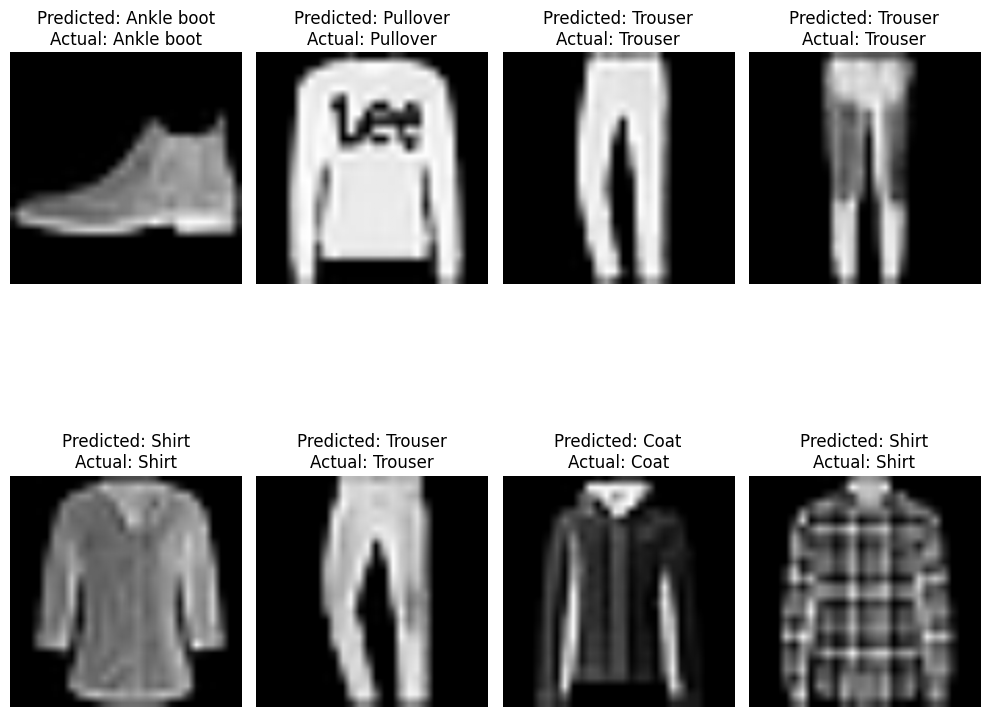

In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
model.eval()
images,labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
  outputs = model(images)
  _, predicted = torch.max(outputs, 1)
plt.figure(figsize=(10, 10))
for i in range(8):
  plt.subplot(2,4,i+1)
  img = images[i].cpu().permute(1,2,0)
  img =(img*0.5)+0.5
  plt.imshow(img)
  plt.title(f"Predicted: {classes[predicted[i]]}\nActual: {classes[labels[i]]}")
  plt.axis('off')
plt.tight_layout()
plt.show()


###Saving the model

In [ ]:
torch.save(model.state_dict(),"q3_vgg16_transfer_learning.pth")
print("Model Saved")

Model Saved


##Q3 Analysis and Discussion


*   This experiment applies transfer learning using a pretrained VGG16 model on the FashionMNIST dataset.Since VGG16 is originally trained on ImageNet, the final classification layer was replaced with a new fully connected layer containing 10 output classes for FashionMNIST.
*   All pretrained convolution layers were frozen ande only the fianl classifier layer was trained.This reduces training time and allows the model to reuse previously learned visual features
* The training losss gradually decreased during training successful learning and convergence . The model achieved a test accuracy of  84.54% which demonstrates that transfer learning is highly effective even when the source and target datasets are  different.
* Sample predictions show that the model correctly identifies most clothing categories, although visually simialr clases such as Shirt and T shirt may occasionally create confusion.
* Overall transfer learning with pretrained VGG16 provides faster convergence and strong performace compared to training a deep network from scratch.



#**Q4-VGG16 Trainng**

This section trains VGG16 from scratch on the Fashion MNIST dataset without using pretrained Image Net weights.The purrpose is to compare the perfomance of training from scracth versus transfer learning and evaluate the benefits of pretrained feature extraction

In [ ]:
model_scratch  =models.vgg16(pretrained =False)

#Replacing final Layer for 10 classes
model_scratch.classifier[6] = nn.Linear(
    model_scratch.classifier[6].in_features, 10
)
model_scratch = model_scratch.to(device)
print(model_scratch)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Optimizer Cell

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)
epochs = 2

## Training Loop

In [ ]:
for epoch in range(epochs):
    model_scratch.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_scratch.zero_grad()

        outputs = model_scratch(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_scratch.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/2], Loss: 2.3258
Epoch [2/2], Loss: 2.3029


## Test Accuracy

In [ ]:
model_scratch.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_scratch(images)
        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 10.00%


## Saving Model

In [ ]:
torch.save(model_scratch.state_dict(),"q4_vgg16_scratch.pth")
print("Model Saved")

##**Q4 Analysis and Comaprison**

 * In this experiment VGG16 was trained from scratch without using pretrained ImageNet weights.Unlike transfer learning all parameters were initialized randomly and trained entirely on th FashionMNIST dataset .

 * The training loss remained high and the final tesst accuracy was only 10.00% which is significantly lower than the pretrained VGG16 model used in Q3(84.54%).

 * This happened becasue training a very deep network like VGG16 from scracth requires a much larger dataset and longer training time.With only a smaller number of epochs and limited computational resources the model was unable to learn strong feature representations.

 * This comparison clearly demonstrates the importance of transfer learning.Pretrained models provide better feature extraction faster convergence and much stronger performance when working with the limited datasets such as Fashion MNIST.

 * Overall transfer learning is far more effective than training from scratch in this scenario.




#**Q6 - Gnerative Adversarial Network (GAN)**
This section implements a basic GAN modelfor image generation using the FashionMNIST dataset.The goal is to train a Generator creates fake FashionMNIST images ans the Discriminator learns to distinguish between real and fake images.This helps demonstrate generative learning and compress with previous discriminative models such as VGG16

In [1]:
import torch.nn.functional as F
from torchvision.utils import save_image


##**Generator Model**

In [2]:
class Dicriminator(nn.Modeule):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(28*28 ,512),
        nn.LeakyReLU(0.2),
        nn.Linear(512,512),
        nn.LeakyReLU(0.2),
        nn.Linear(256,1),
        nn.Sigmoid()
    )
  def forward(self,img):
    img_flat = img.view(img.size(0),-1)
    validity = self.model(img_flat)
    return validity


NameError: name 'nn' is not defined